# Loading Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.dummy import DummyClassifier
from scipy.stats import randint, uniform
from xgboost import XGBClassifier


In [2]:
# Load dataset
!git clone https://github.com/Leo-Thomas/EngineFaultDB.git
df = pd.read_csv('/content/EngineFaultDB/EngineFaultDB_Final.csv')
df = df.drop_duplicates()

fatal: destination path 'EngineFaultDB' already exists and is not an empty directory.


In [3]:
df.head()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926
2,0,3.539,1.899,7.578,5.100,1208.505,2.976,11.926,24.213,0.464,200.367,14.443,1.099,1.072,15.754
3,0,3.519,1.889,7.371,5.255,1164.127,2.908,11.786,24.407,0.471,195.345,13.853,1.076,1.006,14.787
4,0,3.549,1.879,7.405,5.177,1172.032,2.898,12.169,24.875,0.468,194.979,13.752,1.060,0.984,14.470


# Transformation

## (BEST!!!)Original + PCA

Removed 0 near-duplicate rows after rounding.


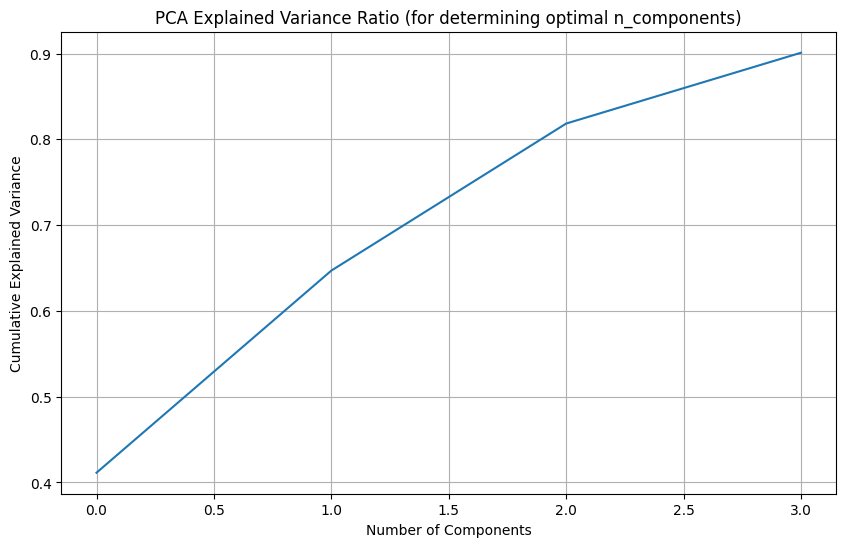

Train shape: (45218, 14)
Test shape: (10780, 14)
Train class distribution:
Fault_Combined
0    0.279513
1    0.209828
2    0.510659
Name: proportion, dtype: float64
Test class distribution:
Fault_Combined
0    0.311781
1    0.140074
2    0.548145
Name: proportion, dtype: float64
Number of KMeans groups: 80
Overlapping KMeans groups between train and test: 0
Exact overlapping feature rows between train and test: 0


In [4]:
def add_engine_features(df):
    # use USE_ENGINEERED_FEATURES=False below to test feature engineering is not causing leakage.
    df = df.copy()
    eps = 1e-8
    df['load_index'] = df['MAP'] * df['TPS'] / (df['RPM'] + eps)
    df['power_per_rpm'] = df['Power']/(df['RPM']+eps)
    df['lambda_dev'] = np.abs(df['Lambda'] - 1)
    df['afr_dev'] = np.abs(df['AFR'] - 14.7)
    df['o2_co2_ratio'] = df['O2']/(df['CO2']+eps)
    df['co2_minus_o2'] = df['CO2'] - df['O2']
    df['combustion_efficiency'] = df['CO2']/(df['CO2']+df['CO']+df['HC']/1e4+eps)
    df['rich_flag'] = (df['Lambda'] < 1).astype(int)
    df['map_x_tps'] = df['MAP']*df['TPS']
    df['rpm_tps_ratio'] = df['RPM'] / (df['TPS'] + eps)
    df['map_rpm_ratio'] = df['MAP'] / (df['RPM'] + eps)
    df['power_load_ratio'] = df['Power'] / (df['MAP'] * df['TPS'] + eps)
    df['lambda_x_load'] = df['Lambda'] * df['load_index']
    df['afr_x_load'] = df['AFR'] * df['load_index']
    df['hc_co_ratio'] = df['HC'] / (df['CO'] + eps)
    df['co_hc_combined'] = df['CO'] + df['HC'] / 1000
    df['emission_intensity'] = (df['CO'] + df['HC']/1000 + df['CO2']) / (df['Power'] + eps)
    df.replace([np.inf, -np.inf], 0, inplace=True)
    df.fillna(0, inplace=True)
    return df

from sklearn.decomposition import PCA

def make_kmeans_condition_groups(X, n_clusters=80, random_state=42):
    X_for_grouping = X.copy()
    X_for_grouping = X_for_grouping.replace([np.inf, -np.inf], np.nan).fillna(0)

    group_scaler = StandardScaler()
    X_group_scaled = group_scaler.fit_transform(X_for_grouping)

    # Apply PCA before KMeans clustering to get explained variance for plotting
    pca_full = PCA(n_components=4, random_state=random_state)
    pca_full.fit(X_group_scaled)

    # Plot explained variance ratio
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Explained Variance Ratio (for determining optimal n_components)')
    plt.grid(True)
    plt.show()

    # Re-initialize PCA with the desired variance retention (or fixed number of components)
    pca = PCA(n_components=4, random_state=random_state) # Retain 95% of variance as initially planned
    X_pca = pca.fit_transform(X_group_scaled)

    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    groups = kmeans.fit_predict(X_pca)
    return pd.Series(groups, index=X.index, name='kmeans_group')



# classes 2 and 3 combined due to similarity
df['Fault_Combined'] = df['Fault'].replace({3: 2})


X_base = df.drop(['Fault', 'Fault_Combined'], axis=1)
y = df['Fault_Combined']

# Optional aggressive near-duplicate removal
AGGRESSIVE_NEAR_DUPLICATE_REMOVAL = True

if AGGRESSIVE_NEAR_DUPLICATE_REMOVAL:
    temp = X_base.round(3).copy()
    temp['Fault_Combined'] = y.values
    before = len(temp)
    temp = temp.drop_duplicates()
    after = len(temp)
    print(f'Removed {before - after} near-duplicate rows after rounding.')
    y = temp['Fault_Combined']
    X_base = temp.drop(columns=['Fault_Combined'])


from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import f1_score
from xgboost import XGBClassifier

# Leakage-aware KMeans grouped split
groups = make_kmeans_condition_groups(X_base, n_clusters=80, random_state=42)

# Final hold-out split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_base, y, groups=groups))

X_train_base = X_base.iloc[train_idx].copy()
X_test_base = X_base.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

USE_ENGINEERED_FEATURES = False

if USE_ENGINEERED_FEATURES:
    X_train_raw = add_engine_features(X_train_base)
    X_test_raw = add_engine_features(X_test_base)
else:
    X_train_raw = X_train_base.copy()
    X_test_raw = X_test_base.copy()

# Safety checks
train_groups = set(groups_train)
test_groups = set(groups_test)
group_overlap = train_groups.intersection(test_groups)

print('Train shape:', X_train_raw.shape)
print('Test shape:', X_test_raw.shape)
print('Train class distribution:')
print(y_train.value_counts(normalize=True).sort_index())
print('Test class distribution:')
print(y_test.value_counts(normalize=True).sort_index())
print('Number of KMeans groups:', groups.nunique())
print('Overlapping KMeans groups between train and test:', len(group_overlap))

overlap_rows = pd.merge(
    X_train_raw.reset_index(drop=True),
    X_test_raw.reset_index(drop=True),
    how='inner'
)
print('Exact overlapping feature rows between train and test:', len(overlap_rows))

# Scale hold-out data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Model Evaluation

## Base Model

In [5]:
# Macro-F1 metric
def macro_f1_eval(y_pred_probs, dtrain):
    y_true = dtrain.get_label()
    y_pred_probs = y_pred_probs.reshape(len(y_true), -1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    return 'macro_f1', f1_score(y_true, y_pred, average='macro')

model = XGBClassifier(
    objective='multi:softprob',
    eval_metric=macro_f1_eval,
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))
print('Macro-F1:', f1_score(y_test, y_pred, average='macro'))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3361
           1       1.00      1.00      1.00      1510
           2       1.00      1.00      1.00      5909

    accuracy                           1.00     10780
   macro avg       1.00      1.00      1.00     10780
weighted avg       1.00      1.00      1.00     10780

Macro-F1: 0.9994026279061133


## Tuned Model

In [6]:
tuned_params = {
    'colsample_bytree': 0.7933755828319241,
    'gamma': 0.482627653632069,
    'learning_rate': 0.1110551371530027,
    'max_depth': 7,
    'min_child_weight': 1,
    'n_estimators': 356,
    'reg_alpha': 0.8021969807540397,
    'reg_lambda': 1.7455064367977082,
    'subsample': 0.9947547746402069
}

new_xgb_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric=macro_f1_eval,
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
    **tuned_params
)

new_xgb_model.fit(X_train, y_train)

y_pred_tuned = new_xgb_model.predict(X_test)

print('Classification Report (XGBoost with Tuned Parameters - KMeans Grouped Split):')
print(classification_report(y_test, y_pred_tuned, zero_division=0))
print('Macro-F1:', f1_score(y_test, y_pred_tuned, average='macro'))

Classification Report (XGBoost with Tuned Parameters - KMeans Grouped Split):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3361
           1       1.00      1.00      1.00      1510
           2       1.00      1.00      1.00      5909

    accuracy                           1.00     10780
   macro avg       1.00      1.00      1.00     10780
weighted avg       1.00      1.00      1.00     10780

Macro-F1: 0.9994026279061133


## Cross Validation and Final Model

In [7]:
# GroupKFold cross-validation on training data only
gkf = GroupKFold(n_splits=5)
cv_scores = []

for fold, (cv_train_idx, cv_val_idx) in enumerate(
    gkf.split(X_train_base, y_train, groups=groups_train), start=1
):
    X_cv_train_base = X_train_base.iloc[cv_train_idx].copy()
    X_cv_val_base = X_train_base.iloc[cv_val_idx].copy()
    y_cv_train = y_train.iloc[cv_train_idx].copy()
    y_cv_val = y_train.iloc[cv_val_idx].copy()

    if USE_ENGINEERED_FEATURES:
        X_cv_train_raw = add_engine_features(X_cv_train_base)
        X_cv_val_raw = add_engine_features(X_cv_val_base)
    else:
        X_cv_train_raw = X_cv_train_base.copy()
        X_cv_val_raw = X_cv_val_base.copy()

    cv_scaler = MinMaxScaler()
    X_cv_train = cv_scaler.fit_transform(X_cv_train_raw)
    X_cv_val = cv_scaler.transform(X_cv_val_raw)

    cv_model = XGBClassifier(
        objective='multi:softprob',
        tree_method='hist',
        num_class=len(y.unique()),
        random_state=99,
        eval_metric='mlogloss',
        **tuned_params
    )

    cv_model.fit(X_cv_train, y_cv_train)
    y_cv_pred = cv_model.predict(X_cv_val)

    fold_score = f1_score(y_cv_val, y_cv_pred, average='macro')
    cv_scores.append(fold_score)

    print(f'Fold {fold} Macro-F1: {fold_score:.4f}')

print('Mean CV Macro-F1:', np.mean(cv_scores))
print('Std CV Macro-F1:', np.std(cv_scores))

Fold 1 Macro-F1: 0.9196
Fold 2 Macro-F1: 0.8335
Fold 3 Macro-F1: 0.8678
Fold 4 Macro-F1: 0.8342
Fold 5 Macro-F1: 0.8253
Mean CV Macro-F1: 0.8560799866437178
Std CV Macro-F1: 0.034969414200613017


## Leakage and overfitting Checks


In [8]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print('Dummy baseline classification report:')
print(classification_report(y_test, dummy_pred, zero_division=0))
print('Dummy baseline Macro-F1:', f1_score(y_test, dummy_pred, average='macro'))

# Label-shuffle sanity check:
y_train_shuffled = y_train.sample(frac=1, random_state=42).to_numpy()

shuffle_model = XGBClassifier(
    objective='multi:softprob',
    tree_method='hist',
    num_class=len(y.unique()),
    random_state=42,
)

shuffle_model.fit(X_train, y_train_shuffled)
shuffle_pred = shuffle_model.predict(X_test)

print('Label-shuffle classification report:')
print(classification_report(y_test, shuffle_pred, zero_division=0))
print('Label-shuffle Macro-F1:', f1_score(y_test, shuffle_pred, average='macro'))

Dummy baseline classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3361
           1       0.00      0.00      0.00      1510
           2       0.55      1.00      0.71      5909

    accuracy                           0.55     10780
   macro avg       0.18      0.33      0.24     10780
weighted avg       0.30      0.55      0.39     10780

Dummy baseline Macro-F1: 0.23604370144007028
Label-shuffle classification report:
              precision    recall  f1-score   support

           0       0.49      0.07      0.12      3361
           1       0.07      0.01      0.01      1510
           2       0.55      0.95      0.70      5909

    accuracy                           0.54     10780
   macro avg       0.37      0.34      0.28     10780
weighted avg       0.47      0.54      0.42     10780

Label-shuffle Macro-F1: 0.2767331785267855


In [9]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

y_pred_train = new_xgb_model.predict(X_train)
train_macro_f1 = f1_score(y_train, y_pred_train, average='macro')

test_macro_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print(f'Tuned Model Training Macro-F1: {train_macro_f1:.4f}')
print(f'Tuned Model Test Macro-F1: {test_macro_f1:.4f}')

if (train_macro_f1 - test_macro_f1) > 0.05:
    print('\nObservation: The training Macro-F1 is significantly higher than the test Macro-F1. This might indicate overfitting.')
elif (train_macro_f1 - test_macro_f1) > 0.01:
    print('\nObservation: There is a noticeable difference between training and test Macro-F1, suggesting some overfitting.')
else:
    print('\nObservation: The training and test Macro-F1 scores are very close, indicating that the model is generalizing well and not significantly overfitting.')

Tuned Model Training Macro-F1: 1.0000
Tuned Model Test Macro-F1: 0.9994

Observation: The training and test Macro-F1 scores are very close, indicating that the model is generalizing well and not significantly overfitting.


# Confusion Matrix

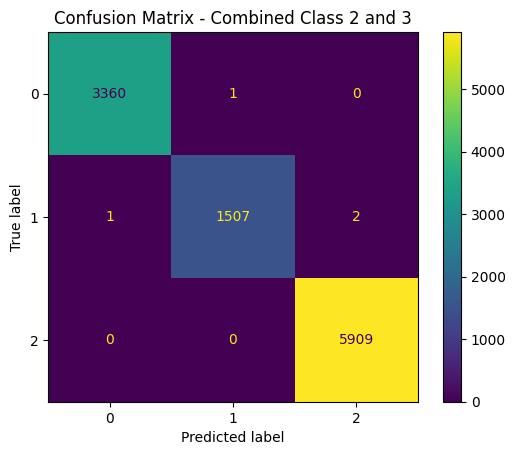

Macro-F1: 0.9994026279061133


In [10]:
cm = confusion_matrix(y_test, y_pred_tuned)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix - Combined Class 2 and 3')
plt.show()

print("Macro-F1:", f1_score(y_test, y_pred_tuned, average='macro'))

# SHAP Explainability


Generating SHAP summary plot for Class 0...


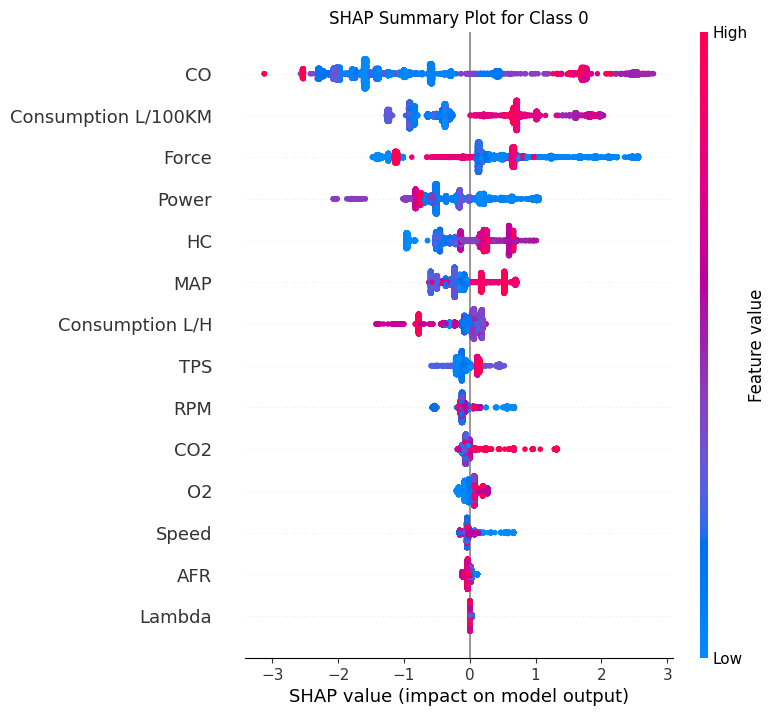


Generating SHAP summary plot for Class 1...


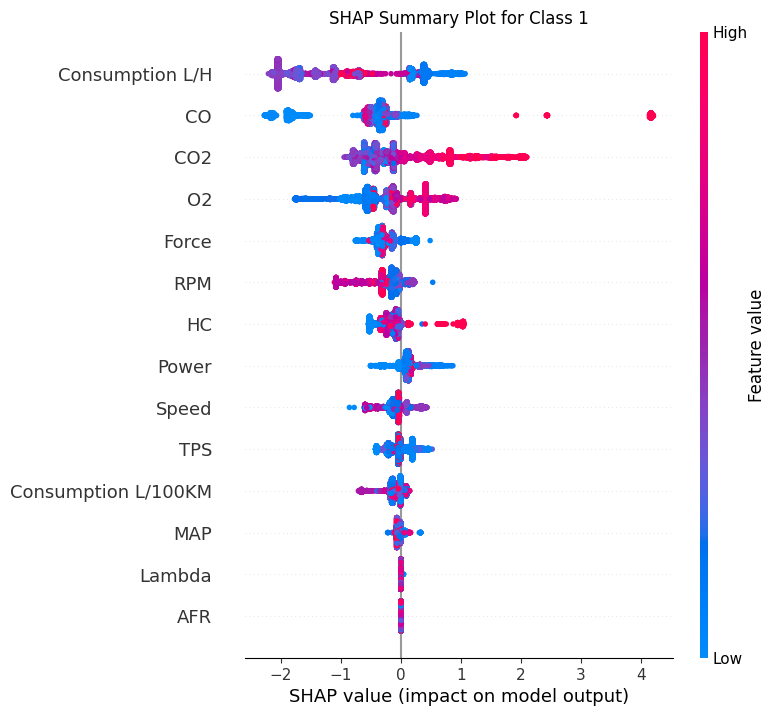


Generating SHAP summary plot for Class 2...


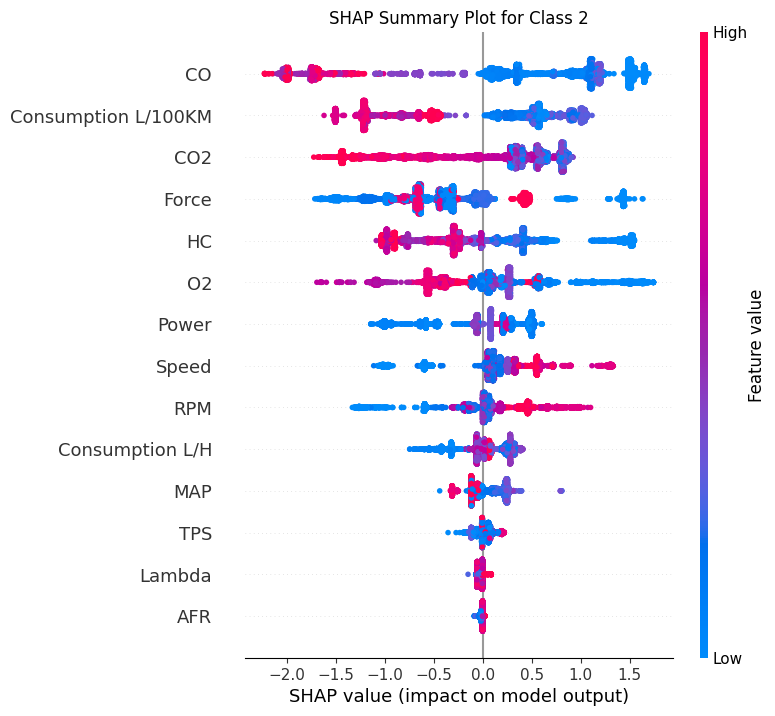

In [11]:
explainer = shap.TreeExplainer(new_xgb_model)
shap_values = explainer.shap_values(X_test)

feature_names = X_train_raw.columns.tolist()

class_labels = sorted(y.unique())

for i in range(len(class_labels)):
    if i < shap_values.shape[2]:
        print(f'\nGenerating SHAP summary plot for Class {class_labels[i]}...')
        shap.summary_plot(shap_values[:, :, i], X_test, feature_names=feature_names, show=False)
        plt.title(f'SHAP Summary Plot for Class {class_labels[i]}')
        plt.show()
    else:
        print(f'Warning: No SHAP values available for class index {i}')

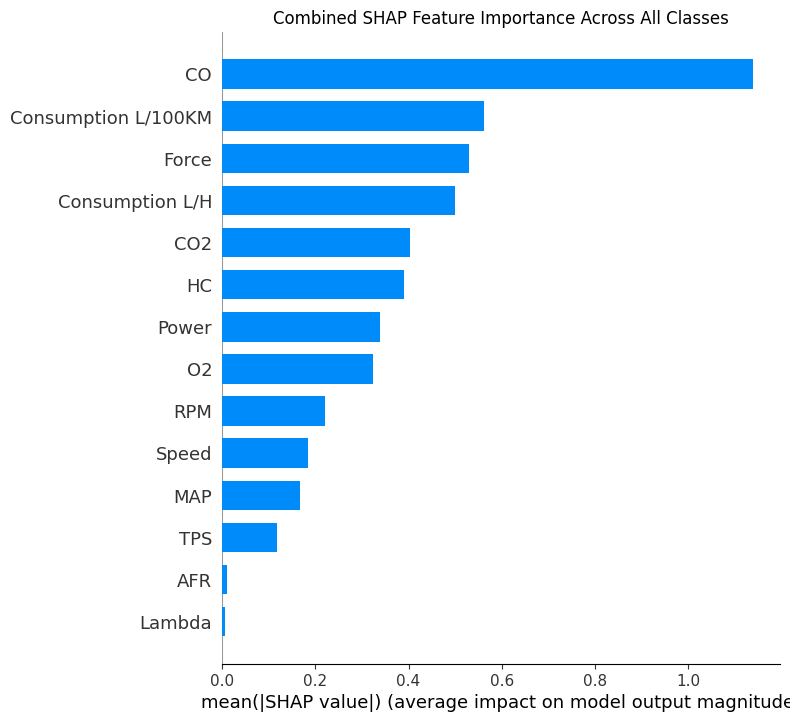

In [12]:
import numpy as np
import shap
import matplotlib.pyplot as plt

# Combine SHAP values across classes but keep sample x feature shape
# Original shape: (n_samples, n_features, n_classes)
shap_combined = np.mean(np.abs(shap_values), axis=2)

# Bar plot across all classes
shap.summary_plot(
    shap_combined,
    X_test,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Combined SHAP Feature Importance Across All Classes")
plt.show()

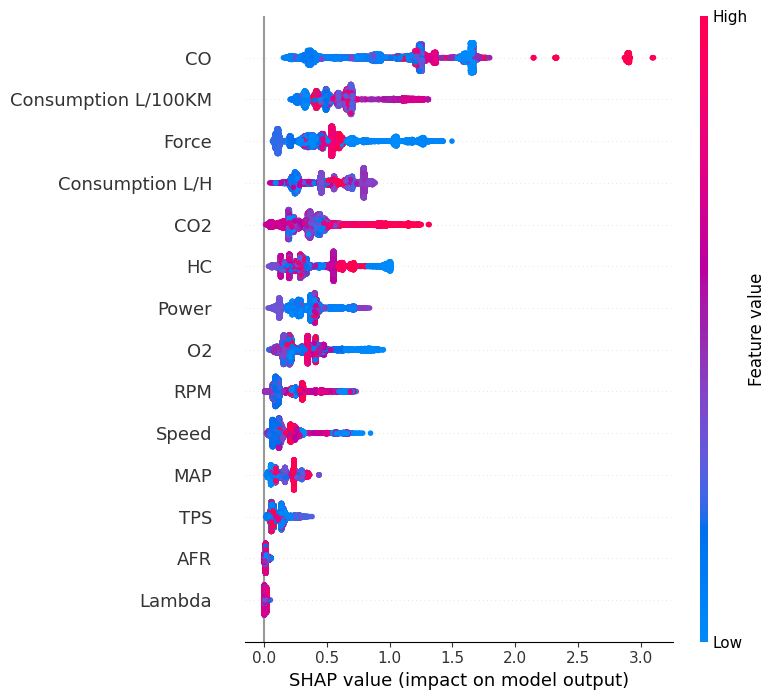

In [13]:
# Mean SHAP importance:

import numpy as np
import shap

# shap_values shape: (n_samples, n_features, n_classes)

# Take mean absolute SHAP across classes
shap_combined = np.mean(np.abs(shap_values), axis=2)

shap.summary_plot(shap_combined, X_test, feature_names=feature_names)